In [1]:
words_pinyin = open('data/names1_pinyin.txt','r').read().splitlines()
words_pinyin[:10],len(words_pinyin)

(['ni|zining',
  'song|yunshen',
  'you|tinglan',
  'tang|chengan',
  'long|zhangning',
  'tian|qingxuan',
  'ke|chuan',
  'zheng|lingwei',
  'ren|yaoyin',
  'wang|yin'],
 11080)

In [2]:
min_len = min(len(w) for w in words_pinyin)
max_len = max(len(w) for w in words_pinyin)

max_i=[i for i,n in enumerate(words_pinyin) if len(n)==max_len]
min_len,max_len,words_pinyin[max_i[0]]

(5, 19, 'shangguan|mingchuan')

In [3]:
chars = sorted(list(set(''.join(words_pinyin))))
len(chars),#chars # a~z + |

(27,)

In [19]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i+1:s for i,s in enumerate(chars)}
itos[0] = '.'

stoi['.'],itos[21]

(0, 'u')

In [9]:
import torch
char_count = stoi.__len__()
N = torch.zeros(char_count,char_count,dtype=torch.int32)

In [16]:
for w in words_pinyin:
    chs = ['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1
N.shape

torch.Size([28, 28])

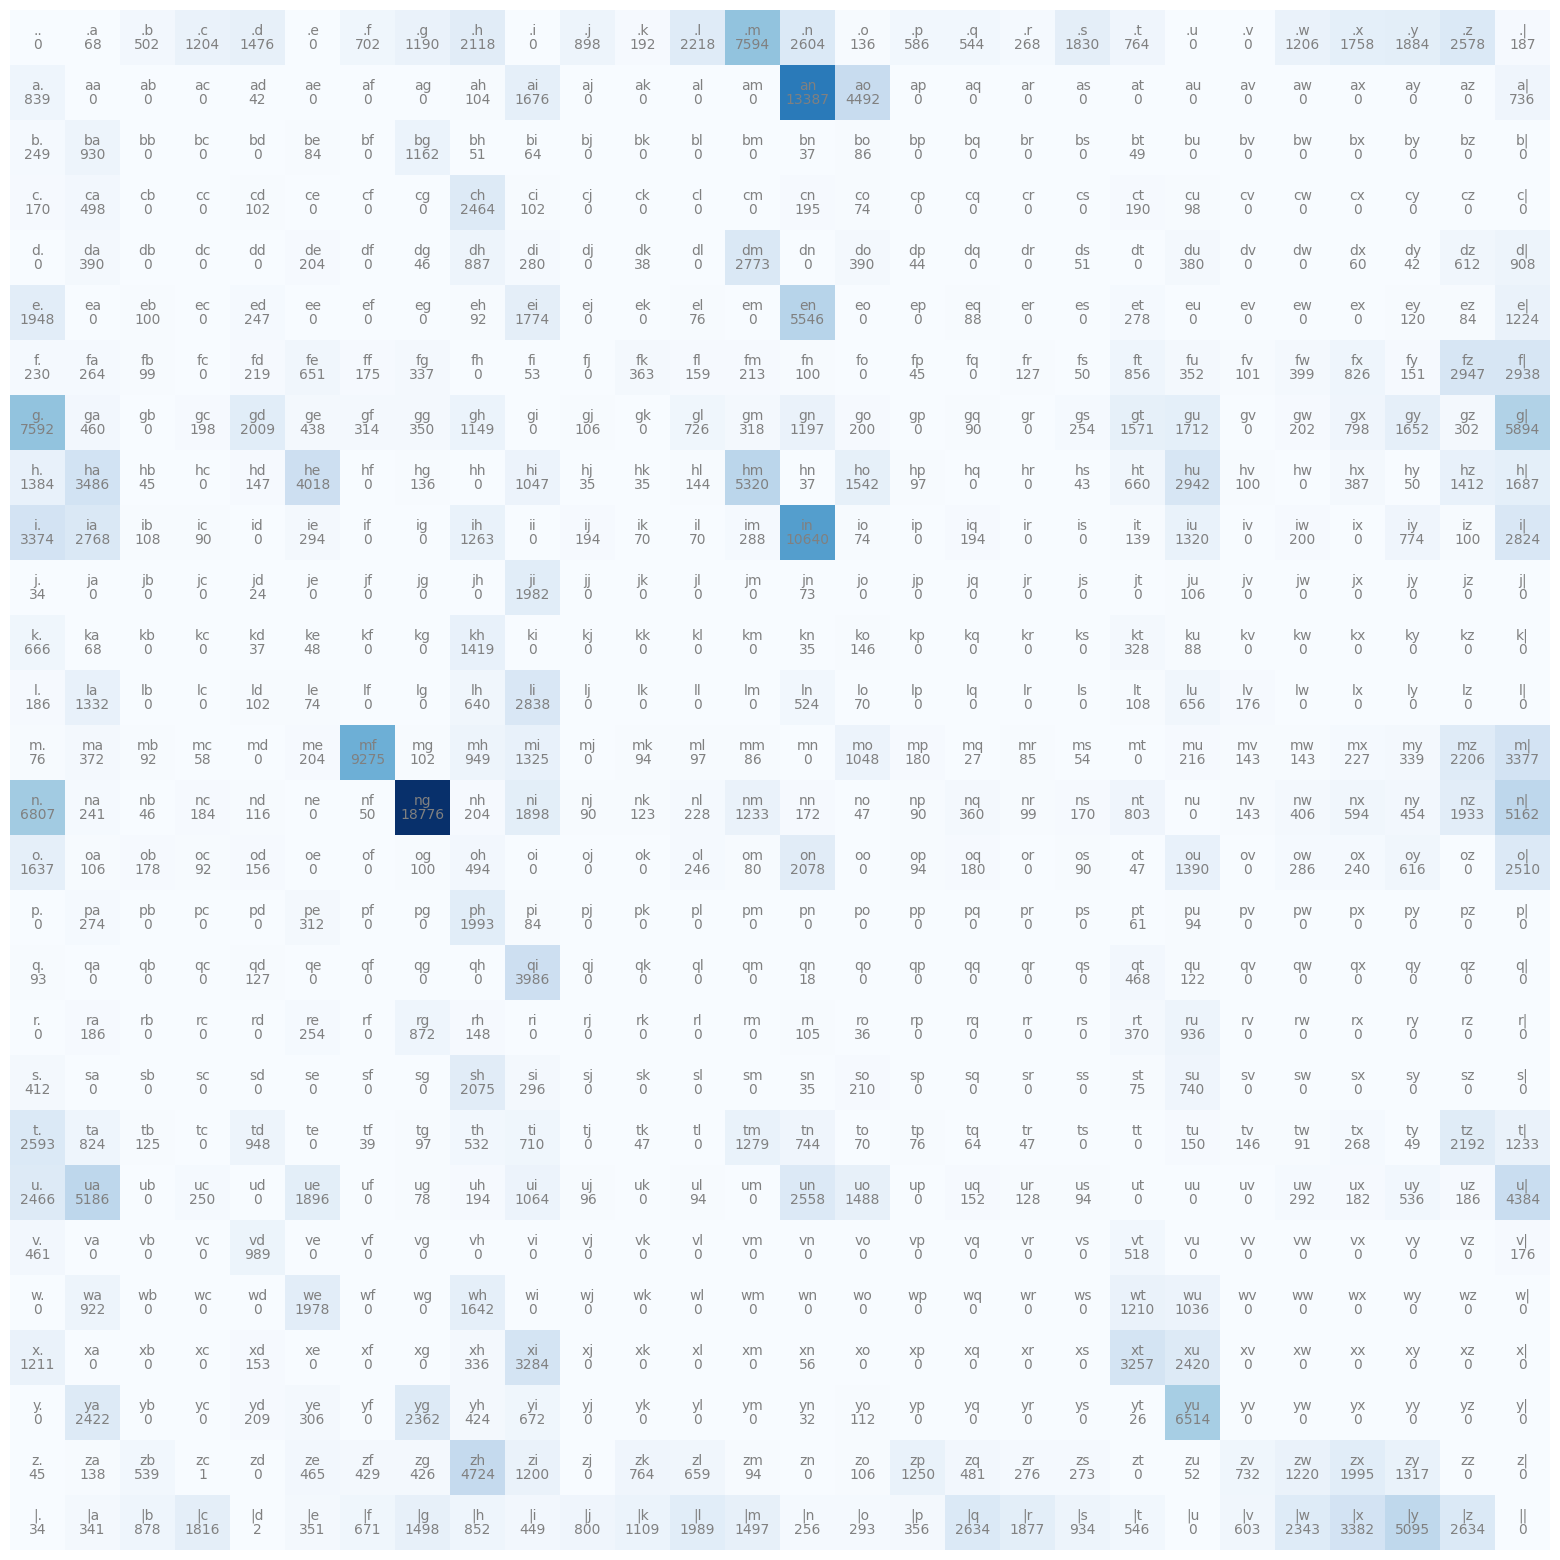

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(20,20))
plt.imshow(N,cmap='Blues')
for i in range(char_count):
    for j in range(char_count):
        chstr=itos[i]+itos[j]
        plt.text(j,i,chstr,ha='center',va='bottom',color='gray')
        plt.text(j,i,N[i,j].item(),ha='center',va='top',color='gray')
plt.axis('off');

In [40]:
p = N[0].float()
p/=p.sum()
p

tensor([0.0000, 0.0021, 0.0154, 0.0370, 0.0454, 0.0000, 0.0216, 0.0366, 0.0652,
        0.0000, 0.0276, 0.0059, 0.0682, 0.2336, 0.0801, 0.0042, 0.0180, 0.0167,
        0.0082, 0.0563, 0.0235, 0.0000, 0.0000, 0.0371, 0.0541, 0.0580, 0.0793,
        0.0058])

In [37]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3,generator=g)
p/=p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [ ]:
torch.multinomial(p,num_samples=20,replacement=True,generator=g)#多项式采样

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [44]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
itos[ix]

'd'

In [48]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    out = []
    ix  = 0
    while True:
        p=N[ix].float()
        p/=p.sum()
        ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out .append(itos[ix])
        if ix==0:
            break
    print(''.join(out))

d|v.
ng|hengjing.
suan|qi.
zl.
min.
shanzxu|yun.
mfi|mf|cang.
shengang|qinzlin.
tan.
shmzfdm|yg|qing.


In [53]:

print(p)
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    ix  = 0
    while True:
        # p=N[ix].float()
        # p/=p.sum()
        p = torch.ones(28)/28
        ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out .append(itos[ix])
        if ix==0:
            break
    print(''.join(out))

tensor([0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357,
        0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357,
        0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357, 0.0357,
        0.0357])
cdvwif||ecajzwp.
aidaotrzpl.
mirqsdhkdbu|oyx.
oki|minaswcjs|enhahlqqyazlqh.
tav.
.
|bvfdneyg|bfcdchsuefyukrbpsjahubrnjdyhxnctkheyezbigzjwa.
nowfjeltcpm.
rlbnicqnwdwqkfnoaddqxrazkekxrxynvm|eiiy|swjaktwptlfovecr|kgygr|zqksz|owpeijshazmm.
orby.
nhxedmgtwlbpwubabjl|jtvzllofjrqxs||ejnivoj.
wtjkycxvozjzgvur.
nwzeyflzqhpme.
rwddqlm.
pdhiw.
ceavnra|iv.
pfbevibzjfcdqbqxhgwhnjsiqazpvy|gnooxktivj|zxvvpffowqxdtqvujbyhtxhixolfggxba.
zgvyeisyypbxqjwrjpmrwooomcteokvjg|smnlj|lesfevykuqbnelncz.
|xpkvggdmg.
nfdteceogszp|jvepmblwrfba.


In [60]:
N.shape

torch.Size([28, 28])

In [65]:
P = N.float()
P.sum(1,keepdim=True).shape#按行方向求和，保留行，压缩列
# tensor 除法的广播机制
# 从尾部对齐
# 28 28
# 28 1
# 维度必须一样，或者一个为 1 或者不存在（扩充）


# keepdim = False
# error!
# 28 28
#    28
P/=P.sum(1,keepdim=True)
P.shape

torch.Size([28, 28])

In [66]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    out = []
    ix  = 0
    while True:
        ix = torch.multinomial(P[ix],num_samples=1,replacement=True,generator=g).item()
        out .append(itos[ix])
        if ix==0:
            break
    print(''.join(out))

d|v.
ng|hengjing.
suan|qi.
zl.
min.
shanzxu|yun.
mfi|mf|cang.
shengang|qinzlin.
tan.
shmzfdm|yg|qing.


In [71]:
# nll: negetive log likeihood

for w in words_pinyin[:2]:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        prob=P[ix,ix2]
        print(f'{ch1}{ch2}: {prob:.4f}')


.n: 0.0801
ni: 0.0000
i|: 0.0058
|z: 0.0793
zi: 0.0000
in: 0.0801
ni: 0.0000
in: 0.0801
ng: 0.0366
g.: 0.0000
.s: 0.0563
so: 0.0042
on: 0.0801
ng: 0.0366
g|: 0.0058
|y: 0.0580
yu: 0.0000
un: 0.0801
ns: 0.0563
sh: 0.0652
he: 0.0000
en: 0.0801
n.: 0.0000
